<a href="https://colab.research.google.com/github/samteccmrj/wed2026/blob/main/wed2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# BLOCO 1 - IMPORTAÇÃO E INSPEÇÃO INICIAL DOS DADOS
# ============================================================

import pandas as pd
import numpy as np
from google.colab import files

# Upload do arquivo anonimizado
uploaded = files.upload()

# Identifica automaticamente o arquivo Excel enviado
arquivo = next(iter(uploaded))

# Leitura do dataset
df_original = pd.read_excel(arquivo)

print("=" * 70)
print("INFORMAÇÕES INICIAIS DO DATASET")
print("=" * 70)

print(f"\nArquivo: {arquivo}")
print(f"Número de participantes: {df_original.shape[0]}")
print(f"Número de variáveis: {df_original.shape[1]}")

print("\nCOLUNAS DO DATASET:")
for i, coluna in enumerate(df_original.columns, start=1):
    print(f"{i}. {coluna}")

print("\nTIPOS DAS VARIÁVEIS:")
print(df_original.dtypes)

print("\nVALORES AUSENTES POR VARIÁVEL:")
print(df_original.isna().sum())

# ------------------------------------------------------------
# Base utilizada nas análises
# ------------------------------------------------------------

df = df_original.copy()

# Remove identificador que não será utilizado nas análises
if "participante" in df.columns:
    df = df.drop(columns=["participante"])

print("\n" + "=" * 70)
print("BASE UTILIZADA NAS ANÁLISES")
print("=" * 70)

print(f"Participantes: {df.shape[0]}")
print(f"Variáveis analisadas: {df.shape[1]}")

print("\nColunas mantidas:")
for coluna in df.columns:
    print(f"- {coluna}")

Saving wed2026.xlsx to wed2026.xlsx
INFORMAÇÕES INICIAIS DO DATASET

Arquivo: wed2026.xlsx
Número de participantes: 84
Número de variáveis: 13

COLUNAS DO DATASET:
1. participante
2. ano_escolar
3. codigo
4. Q1
5. Q2
6. Q3
7. Q4
8. Q5
9. comentario_anonimizado
10. conteudo_analisavel
11. valencia
12. codigos_tematicos
13. categorias_tematicas

TIPOS DAS VARIÁVEIS:
participante              object
ano_escolar               object
codigo                    object
Q1                         int64
Q2                         int64
Q3                         int64
Q4                         int64
Q5                         int64
comentario_anonimizado    object
conteudo_analisavel       object
valencia                  object
codigos_tematicos         object
categorias_tematicas      object
dtype: object

VALORES AUSENTES POR VARIÁVEL:
participante              0
ano_escolar               0
codigo                    0
Q1                        0
Q2                        0
Q3                

In [2]:
# ============================================================
# BLOCO 2 - DISTRIBUIÇÃO POR ANO ESCOLAR E FUNÇÃO
# ============================================================

print("=" * 70)
print("DISTRIBUIÇÃO DOS PARTICIPANTES")
print("=" * 70)

frequencias_originais = (
    df["ano_escolar"]
    .value_counts(dropna=False)
    .sort_index()
)

for categoria, n in frequencias_originais.items():
    percentual = (n / len(df)) * 100
    print(f"{categoria}: {n} participantes ({percentual:.1f}%)")

print(
    "\nNúmero de categorias distintas:",
    df["ano_escolar"].nunique()
)

DISTRIBUIÇÃO DOS PARTICIPANTES
1º Ano EM: 16 participantes (19.0%)
2º Ano EM: 16 participantes (19.0%)
3º Ano EM: 9 participantes (10.7%)
6º Ano EF: 9 participantes (10.7%)
7º Ano EF: 5 participantes (6.0%)
8º Ano EF: 10 participantes (11.9%)
9º Ano EF: 11 participantes (13.1%)
Agente de Ensino: 8 participantes (9.5%)

Número de categorias distintas: 8


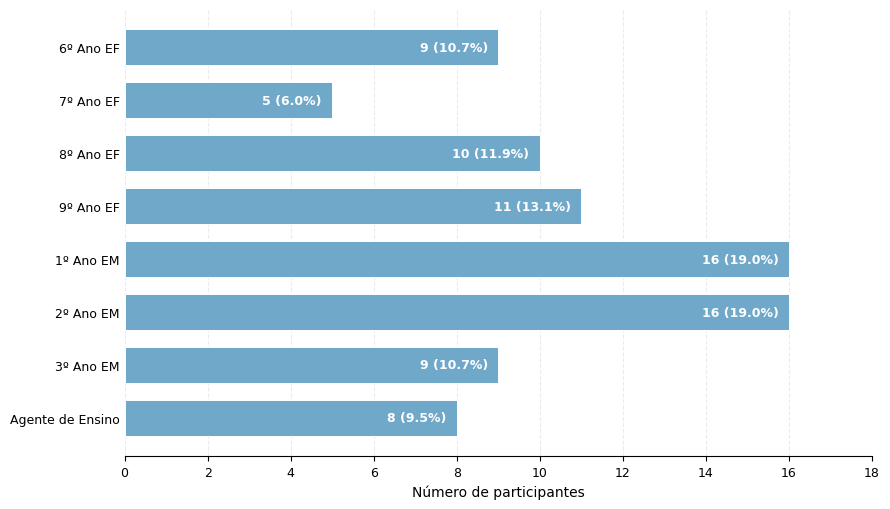

DISTRIBUIÇÃO DOS PARTICIPANTES
6º Ano EF: 9 participantes (10.7%)
7º Ano EF: 5 participantes (6.0%)
8º Ano EF: 10 participantes (11.9%)
9º Ano EF: 11 participantes (13.1%)
1º Ano EM: 16 participantes (19.0%)
2º Ano EM: 16 participantes (19.0%)
3º Ano EM: 9 participantes (10.7%)
Agente de Ensino: 8 participantes (9.5%)

ARQUIVOS GERADOS
distribuicao_participantes.png - resolução de 300 dpi
distribuicao_participantes.pdf - formato vetorial


In [15]:
# ============================================================
# BLOCO 2.1 - DISTRIBUIÇÃO DOS PARTICIPANTES
# POR ANO ESCOLAR E FUNÇÃO
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Ordem das categorias
# ------------------------------------------------------------

ordem_categorias = [
    "6º Ano EF",
    "7º Ano EF",
    "8º Ano EF",
    "9º Ano EF",
    "1º Ano EM",
    "2º Ano EM",
    "3º Ano EM",
    "Agente de Ensino"
]

# ------------------------------------------------------------
# Frequências e percentuais
# ------------------------------------------------------------

distribuicao = (
    df["ano_escolar"]
    .value_counts()
    .reindex(
        ordem_categorias,
        fill_value=0
    )
)

percentuais_participantes = (
    distribuicao
    / len(df)
    * 100
)

# ------------------------------------------------------------
# Paleta
# ------------------------------------------------------------

cor_barra = "#6FA8C9"

# ------------------------------------------------------------
# Criação do gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5.2)
)

barras = ax.barh(
    ordem_categorias,
    distribuicao.values,
    color=cor_barra,
    edgecolor="white",
    linewidth=0.7,
    height=0.68
)

ax.invert_yaxis()

# ------------------------------------------------------------
# Valores dentro das barras
# ------------------------------------------------------------

for barra, n, pct in zip(
    barras,
    distribuicao.values,
    percentuais_participantes.values
):

    ax.text(
        barra.get_width() - 0.25,
        barra.get_y()
        + barra.get_height() / 2,
        f"{n} ({pct:.1f}%)",
        ha="right",
        va="center",
        fontsize=9,
        color="white",
        fontweight="bold"
    )

# ------------------------------------------------------------
# Formatação
# ------------------------------------------------------------

ax.set_xlabel(
    "Número de participantes",
    fontsize=10
)

limite_x = (
    distribuicao.max() + 2
)

ax.set_xlim(
    0,
    limite_x
)

ax.set_xticks(
    np.arange(
        0,
        limite_x + 1,
        2
    )
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(
    axis="y",
    length=0,
    labelsize=9
)

ax.tick_params(
    axis="x",
    labelsize=9
)

plt.tight_layout()

# ------------------------------------------------------------
# Exportação
# ------------------------------------------------------------

plt.savefig(
    "distribuicao_participantes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "distribuicao_participantes.pdf",
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Resultado textual
# ------------------------------------------------------------

print("=" * 70)
print("DISTRIBUIÇÃO DOS PARTICIPANTES")
print("=" * 70)

for categoria in ordem_categorias:

    n = distribuicao[categoria]
    pct = percentuais_participantes[categoria]

    print(
        f"{categoria}: "
        f"{n} participantes "
        f"({pct:.1f}%)"
    )

print("\n" + "=" * 70)
print("ARQUIVOS GERADOS")
print("=" * 70)

print(
    "distribuicao_participantes.png "
    "- resolução de 300 dpi"
)

print(
    "distribuicao_participantes.pdf "
    "- formato vetorial"
)

In [3]:
# ============================================================
# BLOCO 3 - ANÁLISE DESCRITIVA DOS ITENS LIKERT
# ============================================================

colunas_likert = ["Q1", "Q2", "Q3", "Q4", "Q5"]

nomes_curtos = {
    "Q1": "Q1 - Utilidade",
    "Q2": "Q2 - Clareza",
    "Q3": "Q3 - Planejamento",
    "Q4": "Q4 - Interesse",
    "Q5": "Q5 - Otimização do tempo"
}

likert = (
    df[colunas_likert]
    .rename(columns=nomes_curtos)
)

resultados = []

for coluna in likert.columns:

    serie = likert[coluna]

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    resultados.append({
        "Item": coluna,
        "n": serie.count(),
        "Média": serie.mean(),
        "DP": serie.std(),
        "Mediana": serie.median(),
        "Q1": q1,
        "Q3": q3,
        "IIQ": q3 - q1,
        "Top-2 Box (%)": (
            serie.isin([4, 5]).mean() * 100
        )
    })

tabela_descritiva = pd.DataFrame(resultados)

tabela_impressao = tabela_descritiva.copy()

for coluna in [
    "Média",
    "DP",
    "Mediana",
    "Q1",
    "Q3",
    "IIQ",
    "Top-2 Box (%)"
]:
    tabela_impressao[coluna] = (
        tabela_impressao[coluna].round(2)
    )

print("=" * 85)
print("ESTATÍSTICAS DESCRITIVAS DOS ITENS LIKERT")
print("=" * 85)

print(
    tabela_impressao.to_string(
        index=False
    )
)

print("\n" + "=" * 85)
print("DISTRIBUIÇÃO DAS RESPOSTAS")
print("=" * 85)

for coluna in likert.columns:

    print(f"\n{coluna}")

    frequencia = (
        likert[coluna]
        .value_counts()
        .reindex(
            [1, 2, 3, 4, 5],
            fill_value=0
        )
    )

    for resposta in range(1, 6):

        n = frequencia[resposta]
        percentual = (
            n / len(likert) * 100
        )

        print(
            f"  {resposta}: "
            f"{n:2d} participantes "
            f"({percentual:5.1f}%)"
        )

ESTATÍSTICAS DESCRITIVAS DOS ITENS LIKERT
                    Item  n  Média   DP  Mediana  Q1  Q3  IIQ  Top-2 Box (%)
          Q1 - Utilidade 84   4.77 0.63      5.0 5.0 5.0  0.0          94.05
            Q2 - Clareza 84   4.96 0.19      5.0 5.0 5.0  0.0         100.00
       Q3 - Planejamento 84   4.79 0.66      5.0 5.0 5.0  0.0          95.24
          Q4 - Interesse 84   4.58 1.02      5.0 5.0 5.0  0.0          90.48
Q5 - Otimização do tempo 84   4.74 0.58      5.0 5.0 5.0  0.0          95.24

DISTRIBUIÇÃO DAS RESPOSTAS

Q1 - Utilidade
  1:  0 participantes (  0.0%)
  2:  2 participantes (  2.4%)
  3:  3 participantes (  3.6%)
  4:  7 participantes (  8.3%)
  5: 72 participantes ( 85.7%)

Q2 - Clareza
  1:  0 participantes (  0.0%)
  2:  0 participantes (  0.0%)
  3:  0 participantes (  0.0%)
  4:  3 participantes (  3.6%)
  5: 81 participantes ( 96.4%)

Q3 - Planejamento
  1:  1 participantes (  1.2%)
  2:  1 participantes (  1.2%)
  3:  2 participantes (  2.4%)
  4:  7 particip

In [4]:
# ============================================================
# BLOCO 4 - TABELA RESUMIDA PARA O ARTIGO
# ============================================================

tabela_artigo = pd.DataFrame({
    "Dimensão avaliada": [
        "Utilidade para a prática docente",
        "Clareza das atividades",
        "Contribuição para o planejamento",
        "Interesse pelo uso de IA",
        "Otimização do tempo docente"
    ],
    "Média": tabela_descritiva["Média"].round(2),
    "DP": tabela_descritiva["DP"].round(2),
    "Concordância (%)": tabela_descritiva["Top-2 Box (%)"].round(1)
})

print("=" * 80)
print("TABELA 1 - AVALIAÇÃO QUANTITATIVA DO WORKSHOP")
print("=" * 80)

print(tabela_artigo.to_string(index=False))

print("\nNota: Concordância corresponde à soma das respostas 4 e 5")
print("na escala Likert de cinco pontos (Top-2 Box).")
print("N = 84.")

TABELA 1 - AVALIAÇÃO QUANTITATIVA DO WORKSHOP
               Dimensão avaliada  Média   DP  Concordância (%)
Utilidade para a prática docente   4.77 0.63              94.0
          Clareza das atividades   4.96 0.19             100.0
Contribuição para o planejamento   4.79 0.66              95.2
        Interesse pelo uso de IA   4.58 1.02              90.5
     Otimização do tempo docente   4.74 0.58              95.2

Nota: Concordância corresponde à soma das respostas 4 e 5
na escala Likert de cinco pontos (Top-2 Box).
N = 84.


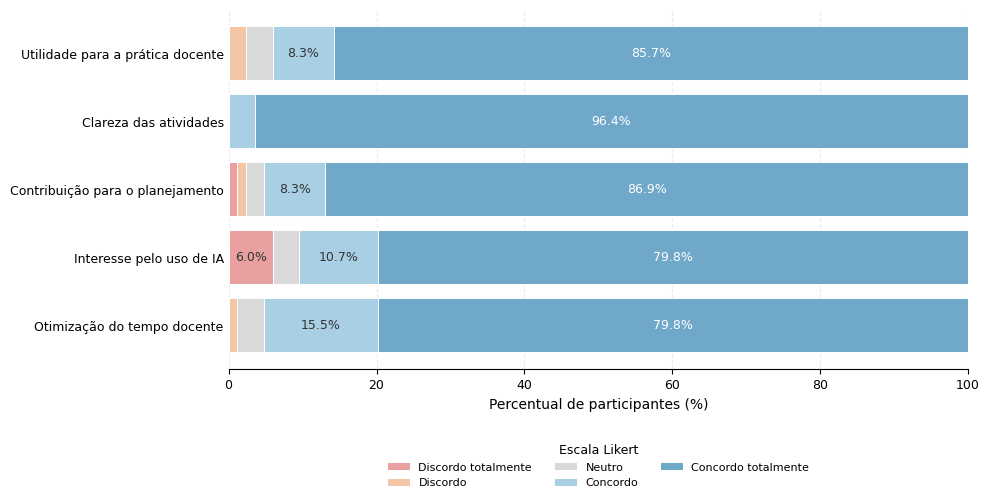

ARQUIVOS GERADOS
avaliacao_workshop_likert.png - resolução de 300 dpi
avaliacao_workshop_likert.pdf - formato vetorial


In [5]:
# ============================================================
# BLOCO 5 - GRÁFICO LIKERT 100% EMPILHADO
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Rótulos curtos dos itens
# ------------------------------------------------------------

rotulos = [
    "Utilidade para a prática docente",
    "Clareza das atividades",
    "Contribuição para o planejamento",
    "Interesse pelo uso de IA",
    "Otimização do tempo docente"
]

# ------------------------------------------------------------
# Calcula os percentuais das respostas 1 a 5
# ------------------------------------------------------------

percentuais = []

for coluna in likert.columns:
    dist = (
        likert[coluna]
        .value_counts(normalize=True)
        .reindex([1, 2, 3, 4, 5], fill_value=0)
        * 100
    )
    percentuais.append(dist.values)

percentuais = np.array(percentuais)

# ------------------------------------------------------------
# Categorias da escala
# ------------------------------------------------------------

categorias = [
    "Discordo totalmente",
    "Discordo",
    "Neutro",
    "Concordo",
    "Concordo totalmente"
]

# ------------------------------------------------------------
# Paleta suave
# ------------------------------------------------------------

cores = [
    "#E8A0A0",  # Discordo totalmente - salmão suave
    "#F3C7A5",  # Discordo - pêssego
    "#D9D9D9",  # Neutro - cinza claro
    "#A9CFE5",  # Concordo - azul claro
    "#6FA8C9"   # Concordo totalmente - azul médio suave
]

# ------------------------------------------------------------
# Criação do gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5.2))

left = np.zeros(len(rotulos))

for i, categoria in enumerate(categorias):

    ax.barh(
        rotulos,
        percentuais[:, i],
        left=left,
        label=categoria,
        color=cores[i],
        edgecolor="white",
        linewidth=0.7
    )

    # --------------------------------------------------------
    # Percentuais dentro das barras
    # Mostra apenas categorias com pelo menos 5%
    # --------------------------------------------------------

    for j, valor in enumerate(percentuais[:, i]):

        if valor >= 5:

            # Texto branco na categoria mais escura
            # e escuro nas demais
            cor_texto = "white" if i == 4 else "#333333"

            ax.text(
                left[j] + valor / 2,
                j,
                f"{valor:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color=cor_texto
            )

    left += percentuais[:, i]

# ------------------------------------------------------------
# Formatação
# ------------------------------------------------------------

# Primeira questão aparece no topo
ax.invert_yaxis()

ax.set_xlabel(
    "Percentual de participantes (%)",
    fontsize=10
)

ax.set_xlim(0, 100)

# Marcação do eixo X
ax.set_xticks(np.arange(0, 101, 20))

# Grade vertical discreta
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

# Garante que a grade fique atrás das barras
ax.set_axisbelow(True)

# Remove bordas desnecessárias
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Remove pequenos traços do eixo Y
ax.tick_params(
    axis="y",
    length=0,
    labelsize=9
)

ax.tick_params(
    axis="x",
    labelsize=9
)

# ------------------------------------------------------------
# Legenda
# ------------------------------------------------------------

ax.legend(
    title="Escala Likert",
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=8,
    title_fontsize=9
)

# ------------------------------------------------------------
# Ajuste do layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# Exportação
# ------------------------------------------------------------

plt.savefig(
    "avaliacao_workshop_likert.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "avaliacao_workshop_likert.pdf",
    bbox_inches="tight"
)

# Exibe no Colab
plt.show()

# ------------------------------------------------------------
# Confirmação
# ------------------------------------------------------------

print("=" * 70)
print("ARQUIVOS GERADOS")
print("=" * 70)
print("avaliacao_workshop_likert.png - resolução de 300 dpi")
print("avaliacao_workshop_likert.pdf - formato vetorial")

In [6]:
# ============================================================
# BLOCO 6 - CARACTERIZAÇÃO DAS RESPOSTAS QUALITATIVAS
# ============================================================

print("=" * 80)
print("CARACTERIZAÇÃO DAS RESPOSTAS QUALITATIVAS")
print("=" * 80)

print(
    f"\nTotal de respostas: {len(df)}"
)

print("\nCONTEÚDO ANALISÁVEL:")
print(
    df["conteudo_analisavel"]
    .value_counts()
)

print("\nVALÊNCIA:")
print(
    df["valencia"]
    .value_counts()
)

n_analisaveis = (
    df["conteudo_analisavel"] == "Sim"
).sum()

print(
    f"\nRespostas com conteúdo analisável: "
    f"{n_analisaveis}"
)

print(
    f"Percentual analisável: "
    f"{n_analisaveis / len(df) * 100:.1f}%"
)

CARACTERIZAÇÃO DAS RESPOSTAS QUALITATIVAS

Total de respostas: 84

CONTEÚDO ANALISÁVEL:
conteudo_analisavel
Sim    60
Não    24
Name: count, dtype: int64

VALÊNCIA:
valencia
Neutra      48
Positiva    32
Negativa     4
Name: count, dtype: int64

Respostas com conteúdo analisável: 60
Percentual analisável: 71.4%


In [7]:
# ============================================================
# BLOCO 7 - FREQUÊNCIA DOS CÓDIGOS TEMÁTICOS
# ============================================================

temas = df[
    df["conteudo_analisavel"] == "Sim"
][
    ["codigo", "codigos_tematicos"]
].copy()

# Divide casos com múltiplos códigos
temas["codigos_tematicos"] = (
    temas["codigos_tematicos"]
    .str.split("|")
)

temas_explodidos = (
    temas
    .explode("codigos_tematicos")
)

temas_explodidos["codigos_tematicos"] = (
    temas_explodidos["codigos_tematicos"]
    .str.strip()
)

frequencia_temas = (
    temas_explodidos["codigos_tematicos"]
    .value_counts()
    .reset_index()
)

frequencia_temas.columns = [
    "Código temático",
    "Frequência"
]

n_analisaveis = (
    df["conteudo_analisavel"] == "Sim"
).sum()

frequencia_temas[
    "% das respostas analisáveis"
] = (
    frequencia_temas["Frequência"]
    / n_analisaveis
    * 100
).round(1)

print("=" * 90)
print("FREQUÊNCIA DOS CÓDIGOS TEMÁTICOS")
print("=" * 90)

print(
    frequencia_temas.to_string(
        index=False
    )
)

print("\n" + "=" * 90)
print("INFORMAÇÕES COMPLEMENTARES")
print("=" * 90)

print(
    f"Respostas com conteúdo analisável: "
    f"{n_analisaveis}"
)

print(
    f"Total de ocorrências temáticas: "
    f"{len(temas_explodidos)}"
)

print(
    f"Número de códigos temáticos distintos: "
    f"{temas_explodidos['codigos_tematicos'].nunique()}"
)

FREQUÊNCIA DOS CÓDIGOS TEMÁTICOS
                          Código temático  Frequência  % das respostas analisáveis
                       avaliação positiva          23                         38.3
                 continuidade da formação          11                         18.3
              adequação à prática docente           6                         10.0
                        novas ferramentas           5                          8.3
                    manutenção do formato           5                          8.3
             novas atividades pedagógicas           4                          6.7
                       adequação temporal           3                          5.0
                    acesso às ferramentas           3                          5.0
                   clareza e objetividade           3                          5.0
                      utilidade percebida           3                          5.0
                    clareza e organização           2 

In [8]:
# ============================================================
# BLOCO 8 - CATEGORIAS TEMÁTICAS
# ============================================================

categorias = df[
    df["conteudo_analisavel"] == "Sim"
][
    ["codigo", "categorias_tematicas"]
].copy()

# Divide respostas pertencentes a mais de uma categoria
categorias["categorias_tematicas"] = (
    categorias["categorias_tematicas"]
    .str.split("|")
)

categorias_explodidas = (
    categorias
    .explode("categorias_tematicas")
)

categorias_explodidas[
    "categorias_tematicas"
] = (
    categorias_explodidas[
        "categorias_tematicas"
    ]
    .str.strip()
)

# Um participante é contado apenas uma vez
# em cada categoria
participantes_categoria = (
    categorias_explodidas[
        ["codigo", "categorias_tematicas"]
    ]
    .drop_duplicates()
)

frequencia_categorias = (
    participantes_categoria[
        "categorias_tematicas"
    ]
    .value_counts()
    .reset_index()
)

frequencia_categorias.columns = [
    "Categoria",
    "Participantes"
]

n_analisaveis = (
    df["conteudo_analisavel"] == "Sim"
).sum()

frequencia_categorias[
    "% das respostas analisáveis"
] = (
    frequencia_categorias["Participantes"]
    / n_analisaveis
    * 100
).round(1)

frequencia_categorias[
    "% do total de participantes"
] = (
    frequencia_categorias["Participantes"]
    / len(df)
    * 100
).round(1)

print("=" * 90)
print("CATEGORIAS TEMÁTICAS FINAIS")
print("=" * 90)

print(
    frequencia_categorias.to_string(
        index=False
    )
)

print("\nNota:")
print(
    "Uma mesma resposta pode pertencer "
    "a mais de uma categoria; portanto, "
    "os percentuais não somam necessariamente 100%."
)

CATEGORIAS TEMÁTICAS FINAIS
                                                  Categoria  Participantes  % das respostas analisáveis  % do total de participantes
       Avaliação e características da experiência formativa             28                         46.7                         33.3
Ampliação e contextualização das possibilidades pedagógicas             17                         28.3                         20.2
                  Continuidade e aprofundamento da formação             12                         20.0                         14.3
                           Condições de realização e acesso              7                         11.7                          8.3

Nota:
Uma mesma resposta pode pertencer a mais de uma categoria; portanto, os percentuais não somam necessariamente 100%.


In [10]:
# ============================================================
# BLOCO 09 - CONSISTÊNCIA INTERNA DOS ITENS
# ALFA DE CRONBACH
# ============================================================

import numpy as np
import pandas as pd

# Seleciona as cinco questões
dados_likert = df[
    ["Q1", "Q2", "Q3", "Q4", "Q5"]
].copy()

# ------------------------------------------------------------
# Função para Alfa de Cronbach
# ------------------------------------------------------------

def cronbach_alpha(df_itens):

    k = df_itens.shape[1]

    variancias_itens = df_itens.var(
        axis=0,
        ddof=1
    )

    escore_total = df_itens.sum(axis=1)

    variancia_total = escore_total.var(ddof=1)

    alpha = (
        k / (k - 1)
    ) * (
        1 - variancias_itens.sum() / variancia_total
    )

    return alpha


# ------------------------------------------------------------
# Alfa geral
# ------------------------------------------------------------

alpha_geral = cronbach_alpha(dados_likert)

print("=" * 75)
print("CONSISTÊNCIA INTERNA DOS CINCO ITENS")
print("=" * 75)

print(
    f"\nAlfa de Cronbach: "
    f"{alpha_geral:.3f}"
)


# ------------------------------------------------------------
# Alfa se cada item for removido
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("ALFA DE CRONBACH SE O ITEM FOR REMOVIDO")
print("=" * 75)

resultados_alpha = []

for item in dados_likert.columns:

    dados_reduzidos = (
        dados_likert.drop(
            columns=[item]
        )
    )

    alpha_sem_item = cronbach_alpha(
        dados_reduzidos
    )

    resultados_alpha.append({
        "Item removido": item,
        "Alfa": round(alpha_sem_item, 3)
    })

resultado_alpha_df = pd.DataFrame(
    resultados_alpha
)

print(
    resultado_alpha_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Correlação item-total corrigida
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CORRELAÇÃO ITEM-TOTAL CORRIGIDA")
print("=" * 75)

resultados_item_total = []

for item in dados_likert.columns:

    outros_itens = (
        dados_likert.drop(
            columns=[item]
        )
    )

    total_sem_item = (
        outros_itens.sum(axis=1)
    )

    correlacao = (
        dados_likert[item]
        .corr(
            total_sem_item,
            method="spearman"
        )
    )

    resultados_item_total.append({
        "Item": item,
        "Correlação item-total": round(
            correlacao,
            3
        )
    })

resultado_item_total_df = pd.DataFrame(
    resultados_item_total
)

print(
    resultado_item_total_df.to_string(
        index=False
    )
)

CONSISTÊNCIA INTERNA DOS CINCO ITENS

Alfa de Cronbach: 0.856

ALFA DE CRONBACH SE O ITEM FOR REMOVIDO
Item removido  Alfa
           Q1 0.773
           Q2 0.912
           Q3 0.772
           Q4 0.817
           Q5 0.804

CORRELAÇÃO ITEM-TOTAL CORRIGIDA
Item  Correlação item-total
  Q1                  0.731
  Q2                  0.288
  Q3                  0.713
  Q4                  0.829
  Q5                  0.764


In [11]:
# ============================================================
# BLOCO 10 - CORRELAÇÃO DE SPEARMAN ENTRE OS ITENS
# ============================================================

from scipy.stats import spearmanr
import pandas as pd

dados_corr = df[
    ["Q1", "Q2", "Q3", "Q4", "Q5"]
].copy()

# ------------------------------------------------------------
# Matriz de correlação
# ------------------------------------------------------------

matriz_spearman = (
    dados_corr.corr(
        method="spearman"
    )
)

print("=" * 75)
print("MATRIZ DE CORRELAÇÃO DE SPEARMAN")
print("=" * 75)

print(
    matriz_spearman
    .round(3)
    .to_string()
)

# ------------------------------------------------------------
# Correlações + valores de p
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CORRELAÇÕES ENTRE OS PARES DE ITENS")
print("=" * 75)

resultados_corr = []

colunas = dados_corr.columns

for i in range(len(colunas)):

    for j in range(i + 1, len(colunas)):

        item1 = colunas[i]
        item2 = colunas[j]

        rho, p = spearmanr(
            dados_corr[item1],
            dados_corr[item2]
        )

        resultados_corr.append({
            "Item 1": item1,
            "Item 2": item2,
            "rho": round(rho, 3),
            "p": p
        })

resultado_corr_df = pd.DataFrame(
    resultados_corr
)

# ------------------------------------------------------------
# Formatação do p
# ------------------------------------------------------------

resultado_corr_df["p_formatado"] = (
    resultado_corr_df["p"]
    .apply(
        lambda x:
        "< 0,001"
        if x < 0.001
        else f"{x:.3f}".replace(".", ",")
    )
)

print(
    resultado_corr_df[
        [
            "Item 1",
            "Item 2",
            "rho",
            "p_formatado"
        ]
    ].to_string(
        index=False
    )
)

MATRIZ DE CORRELAÇÃO DE SPEARMAN
       Q1     Q2     Q3     Q4     Q5
Q1  1.000  0.265  0.866  0.664  0.520
Q2  0.265  1.000  0.106  0.191  0.206
Q3  0.866  0.106  1.000  0.711  0.469
Q4  0.664  0.191  0.711  1.000  0.728
Q5  0.520  0.206  0.469  0.728  1.000

CORRELAÇÕES ENTRE OS PARES DE ITENS
Item 1 Item 2   rho p_formatado
    Q1     Q2 0.265       0,015
    Q1     Q3 0.866     < 0,001
    Q1     Q4 0.664     < 0,001
    Q1     Q5 0.520     < 0,001
    Q2     Q3 0.106       0,337
    Q2     Q4 0.191       0,082
    Q2     Q5 0.206       0,060
    Q3     Q4 0.711     < 0,001
    Q3     Q5 0.469     < 0,001
    Q4     Q5 0.728     < 0,001


In [12]:
# ============================================================
# BLOCO 11 - ANÁLISE DA CONCENTRAÇÃO NAS CATEGORIAS SUPERIORES
# ============================================================

from scipy.stats import skew
import pandas as pd

dados_teto = df[
    ["Q1", "Q2", "Q3", "Q4", "Q5"]
].copy()

resultados_teto = []

for item in dados_teto.columns:

    serie = dados_teto[item]

    percentual_5 = (
        (serie == 5).mean() * 100
    )

    percentual_4_5 = (
        serie.isin([4, 5]).mean() * 100
    )

    percentual_1_2 = (
        serie.isin([1, 2]).mean() * 100
    )

    assimetria = skew(
        serie,
        bias=False
    )

    categorias_usadas = serie.nunique()

    resultados_teto.append({
        "Item": item,
        "% resposta 5": percentual_5,
        "% respostas 4-5": percentual_4_5,
        "% respostas 1-2": percentual_1_2,
        "Assimetria": assimetria,
        "Categorias utilizadas": categorias_usadas
    })

tabela_teto = pd.DataFrame(
    resultados_teto
)

# ------------------------------------------------------------
# Arredondamento
# ------------------------------------------------------------

for coluna in [
    "% resposta 5",
    "% respostas 4-5",
    "% respostas 1-2",
    "Assimetria"
]:
    tabela_teto[coluna] = (
        tabela_teto[coluna].round(2)
    )

print("=" * 90)
print("ANÁLISE DA CONCENTRAÇÃO NAS CATEGORIAS SUPERIORES")
print("=" * 90)

print(
    tabela_teto.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Concentração no valor máximo
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("CONCENTRAÇÃO NA CATEGORIA MÁXIMA DA ESCALA")
print("=" * 90)

for _, linha in tabela_teto.iterrows():

    item = linha["Item"]
    pct5 = linha["% resposta 5"]

    print(
        f"{item}: "
        f"{pct5:.1f}% das respostas na categoria 5"
    )

ANÁLISE DA CONCENTRAÇÃO NAS CATEGORIAS SUPERIORES
Item  % resposta 5  % respostas 4-5  % respostas 1-2  Assimetria  Categorias utilizadas
  Q1         85.71            94.05             2.38       -3.09                      4
  Q2         96.43           100.00             0.00       -5.10                      2
  Q3         86.90            95.24             2.38       -3.86                      5
  Q4         79.76            90.48             5.95       -2.78                      4
  Q5         79.76            95.24             1.19       -2.51                      4

CONCENTRAÇÃO NA CATEGORIA MÁXIMA DA ESCALA
Q1: 85.7% das respostas na categoria 5
Q2: 96.4% das respostas na categoria 5
Q3: 86.9% das respostas na categoria 5
Q4: 79.8% das respostas na categoria 5
Q5: 79.8% das respostas na categoria 5


In [13]:
# ============================================================
# BLOCO 12 - INTEGRAÇÃO QUANTITATIVO-QUALITATIVA
# Participantes com respostas 1, 2 ou 3
# ============================================================

colunas_q = [
    "Q1",
    "Q2",
    "Q3",
    "Q4",
    "Q5"
]

# ------------------------------------------------------------
# Identifica participantes com pelo menos uma resposta <= 3
# ------------------------------------------------------------

mascara_baixa = (
    df[colunas_q] <= 3
).any(axis=1)

casos_baixos = df.loc[
    mascara_baixa,
    [
        "codigo",
        "Q1",
        "Q2",
        "Q3",
        "Q4",
        "Q5",
        "comentario_anonimizado",
        "conteudo_analisavel",
        "valencia"
    ]
].copy()

# ------------------------------------------------------------
# Número de itens entre 1 e 3
# ------------------------------------------------------------

casos_baixos["itens_1a3"] = (
    casos_baixos[colunas_q] <= 3
).sum(axis=1)

# Menor resposta atribuída
casos_baixos["menor_resposta"] = (
    casos_baixos[colunas_q]
    .min(axis=1)
)

# Ordenação dos casos
casos_baixos = (
    casos_baixos
    .sort_values(
        by=[
            "itens_1a3",
            "menor_resposta"
        ],
        ascending=[
            False,
            True
        ]
    )
)

# ------------------------------------------------------------
# Resumo geral
# ------------------------------------------------------------

print("=" * 100)
print("INTEGRAÇÃO QUANTITATIVO-QUALITATIVA")
print("=" * 100)

n_casos = len(casos_baixos)

print(
    f"\nParticipantes com pelo menos uma "
    f"resposta entre 1 e 3: "
    f"{n_casos} de {len(df)} "
    f"({n_casos / len(df) * 100:.1f}%)"
)

# ------------------------------------------------------------
# Participantes com respostas 1-3 por item
# ------------------------------------------------------------

print(
    "\nQuantidade de participantes "
    "com resposta entre 1 e 3 por item:"
)

for q in colunas_q:

    n = (
        df[q] <= 3
    ).sum()

    pct = (
        n / len(df) * 100
    )

    print(
        f"{q}: "
        f"{n} participantes "
        f"({pct:.1f}%)"
    )

# ------------------------------------------------------------
# Valência dos comentários
# ------------------------------------------------------------

print("\nVALÊNCIA DOS COMENTÁRIOS:")

print(
    casos_baixos[
        "valencia"
    ]
    .value_counts()
    .to_string()
)

# ------------------------------------------------------------
# Conteúdo qualitativo analisável
# ------------------------------------------------------------

print(
    "\nCONTEÚDO QUALITATIVO ANALISÁVEL:"
)

print(
    casos_baixos[
        "conteudo_analisavel"
    ]
    .value_counts()
    .to_string()
)

# ------------------------------------------------------------
# Casos anonimizados para interpretação
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("CASOS PARA INTERPRETAÇÃO")
print("=" * 100)

for _, linha in casos_baixos.iterrows():

    print(
        f"\n{linha['codigo']}"
    )

    print(
        f"Q1={linha['Q1']} | "
        f"Q2={linha['Q2']} | "
        f"Q3={linha['Q3']} | "
        f"Q4={linha['Q4']} | "
        f"Q5={linha['Q5']}"
    )

    print(
        f"Itens entre 1-3: "
        f"{linha['itens_1a3']}"
    )

    print(
        f"Valência qualitativa: "
        f"{linha['valencia']}"
    )

    print(
        "Comentário anonimizado: "
        f"{linha['comentario_anonimizado']}"
    )

    print("-" * 100)

INTEGRAÇÃO QUANTITATIVO-QUALITATIVA

Participantes com pelo menos uma resposta entre 1 e 3: 8 de 84 (9.5%)

Quantidade de participantes com resposta entre 1 e 3 por item:
Q1: 5 participantes (6.0%)
Q2: 0 participantes (0.0%)
Q3: 4 participantes (4.8%)
Q4: 8 participantes (9.5%)
Q5: 4 participantes (4.8%)

VALÊNCIA DOS COMENTÁRIOS:
valencia
Neutra      6
Negativa    2

CONTEÚDO QUALITATIVO ANALISÁVEL:
conteudo_analisavel
Não    5
Sim    3

CASOS PARA INTERPRETAÇÃO

R08
Q1=3 | Q2=5 | Q3=3 | Q4=1 | Q5=3
Itens entre 1-3: 4
Valência qualitativa: Neutra
Comentário anonimizado: Sem sugestões adicionais.
----------------------------------------------------------------------------------------------------

R16
Q1=2 | Q2=5 | Q3=1 | Q4=1 | Q5=2
Itens entre 1-3: 4
Valência qualitativa: Negativa
Comentário anonimizado: Considera a ferramenta apresentada pouco útil para sua prática.
----------------------------------------------------------------------------------------------------

R71
Q1=2 | Q2=5 |